In [41]:
import numpy as np
from math import pi, sqrt, log
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import pickle
from scipy.optimize import minimize, root_scalar

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
def theta(u, p: int) -> float:
    e_inf = 2 * np.sqrt((p - 1) / p)
    return (
        0.5 * np.log(p - 1)
        - (p - 2) / (4 * (p - 1)) * u**2
        - np.log(e_inf)
        + np.log(-u + np.sqrt(u**2 - e_inf**2))
        + u / (e_inf**2) * np.sqrt(u**2 - e_inf**2)
    )


def beta(u, p):
    e_inf = 2 * np.sqrt((p - 1) / p)
    return (
        (p / (2 ** (3 / 2) * (p - 1)))
        * (p / (p - 2)) ** ((p - 2) / 2)
        * (-u - np.sqrt(u**2 - e_inf**2))
    )

In [81]:
ps = np.logspace(np.log10(3), 10, 300, dtype=int)
ps = np.unique(ps)
u_star = np.zeros_like(ps, dtype=float)

for i, p in enumerate(ps):
    e_inf = 2 * sqrt((p - 1) / p)
    res = root_scalar(
        lambda u: theta(u, p),
        bracket=[-3 * e_inf, -e_inf],
        method='bisect',
        xtol=1e-10,
        rtol=1e-10
    )

    u_star[i] = res.root

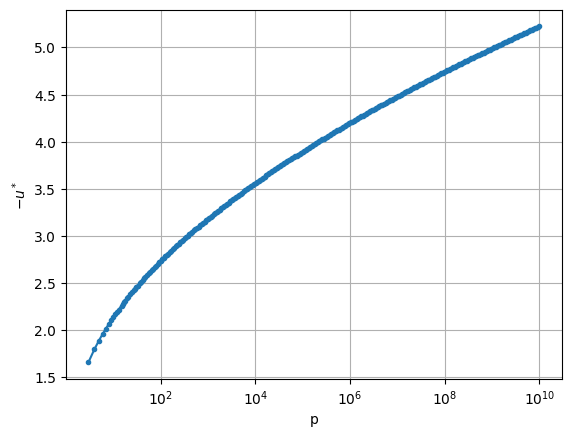

In [91]:
plt.plot(ps, -u_star, ".-",label='Numerical root')
plt.xscale('log')
# plt.yscale('log')
plt.xlabel('p')
plt.ylabel(r'$-u^*$')
plt.grid()

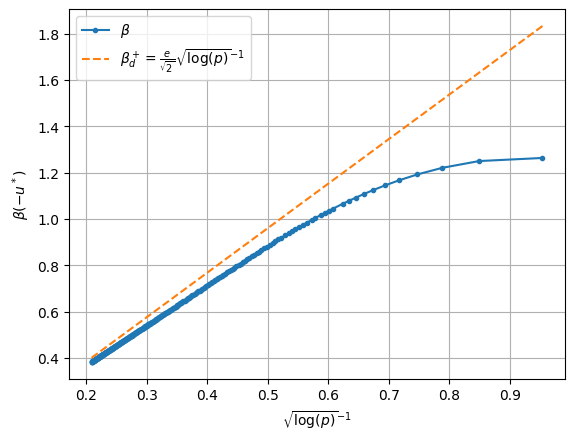

In [101]:
plt.plot(np.sqrt(np.log(ps))**-1, beta(u_star, ps), '.-',label=r'$\beta$')
plt.plot(np.sqrt(np.log(ps))**-1, np.exp(1)/np.sqrt(2) * np.sqrt(np.log(ps))**-1, '--',label=r'$\beta_d^+ = \frac{e}{\sqrt{2}} \sqrt{\log(p)}^{-1}$')
plt.xlabel(r'$\sqrt{\log(p)}^{-1}$')
plt.ylabel(r'$\beta(-u^*)$')
plt.legend()
plt.grid()

plt.savefig('../imgs/ben_arous.pdf', bbox_inches='tight')
plt.savefig('../imgs/ben_arous.png', bbox_inches='tight', dpi=360)